# Разведочный анализ данных: Adult Income

Полный EDA по датасету Adult (`adult.csv`): базовая структура, пропуски, распределения признаков, анализ целевой переменной `income`, корреляции и взаимосвязи признаков с таргетом.


Форма датасета: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K



Типы столбцов:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            325

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0



Описательная статистика категориальных признаков:


...

Series([], dtype: int64)


Распределение целевой переменной:


income
<=50K    24720
>50K      7841
Name: count, dtype: int64


Доля классов:


income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

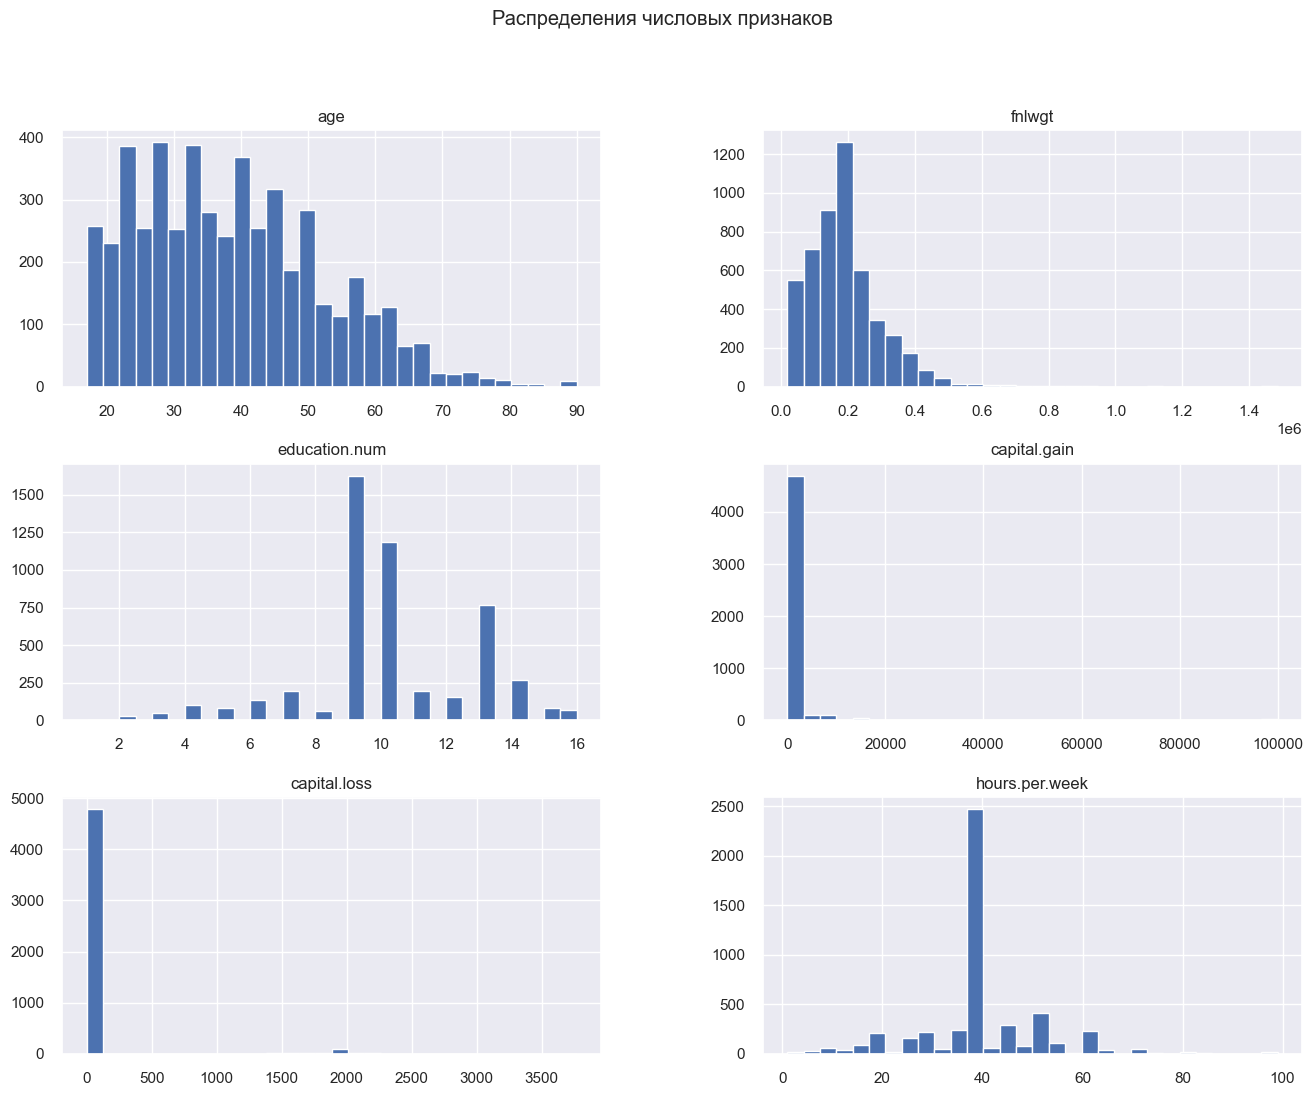

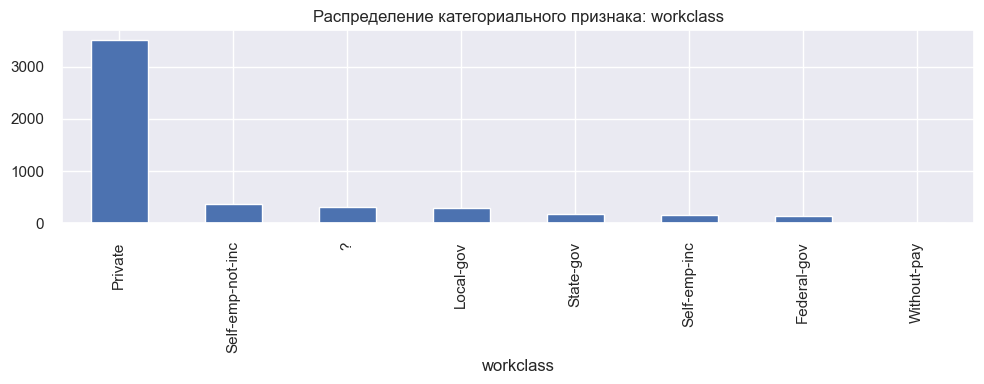

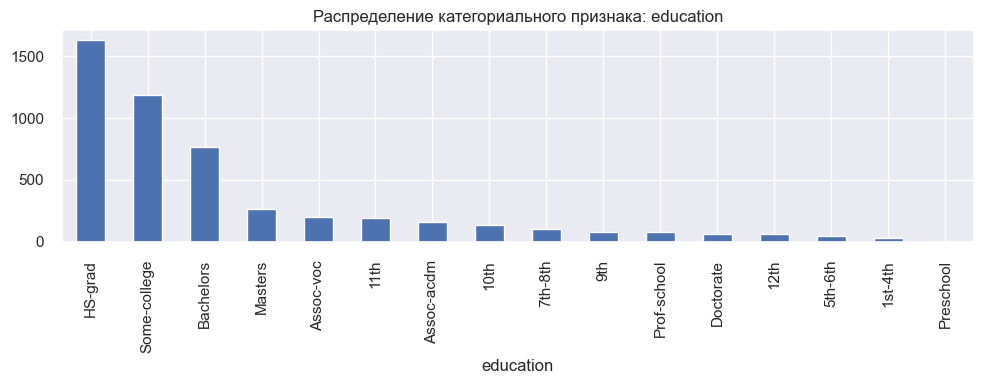

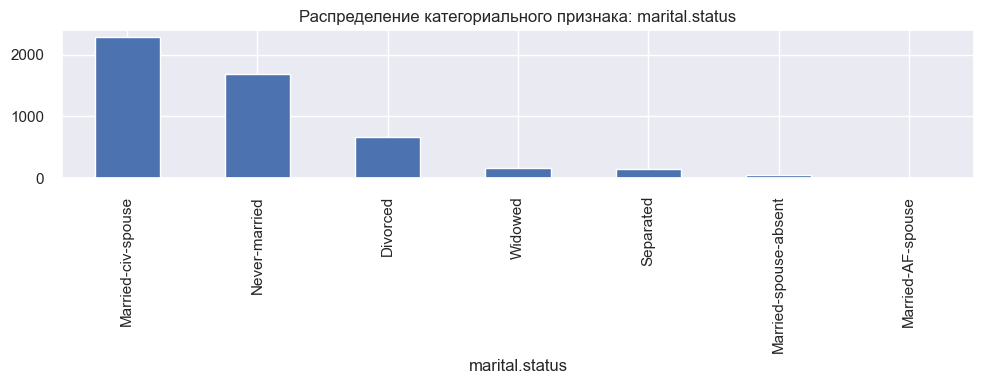

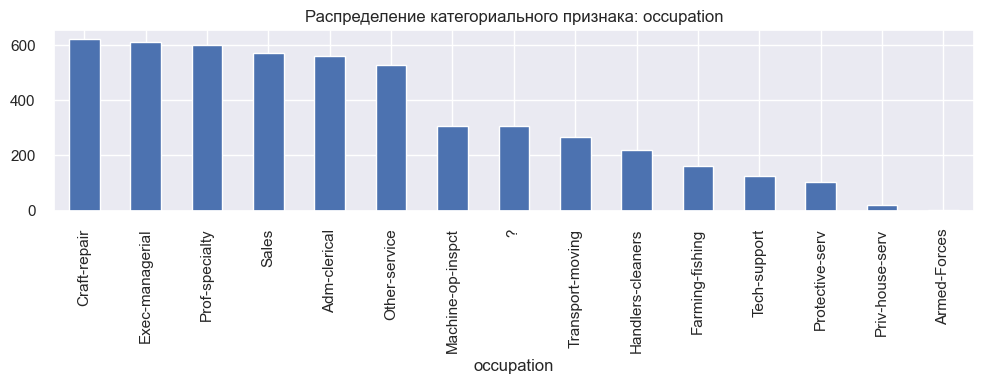

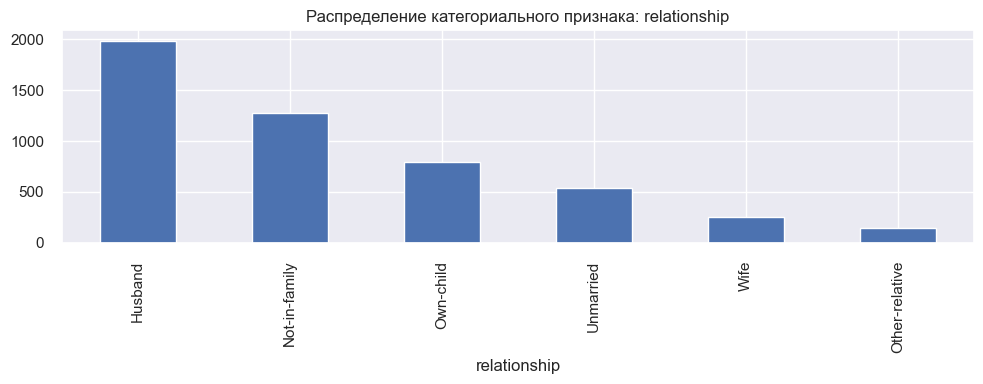

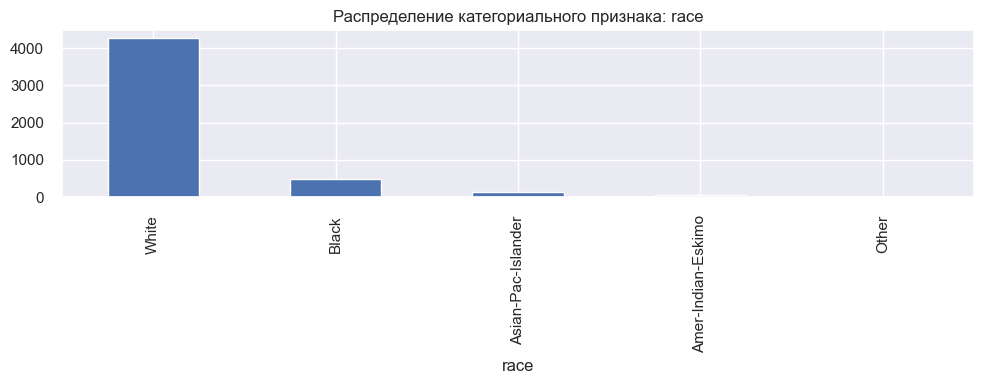

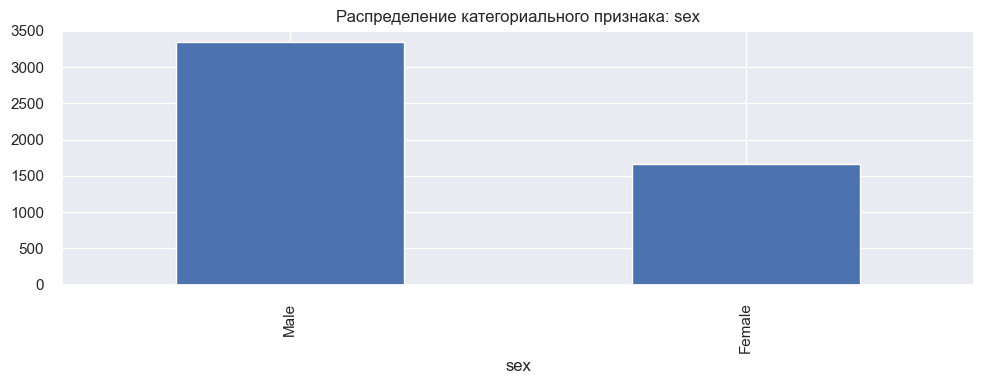

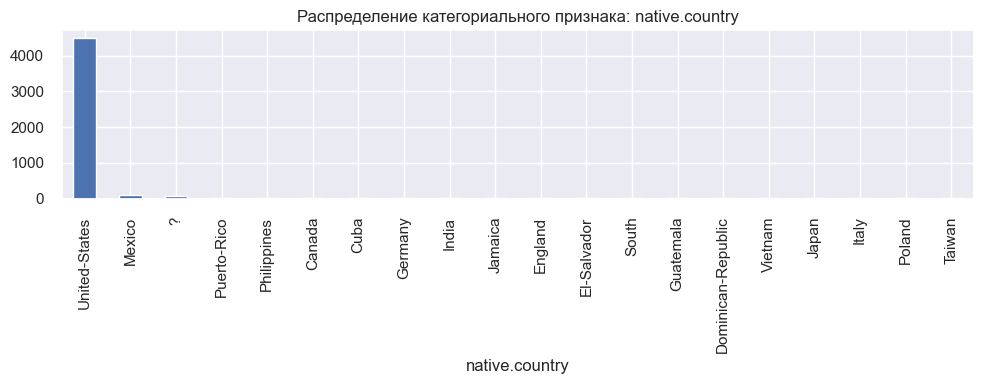

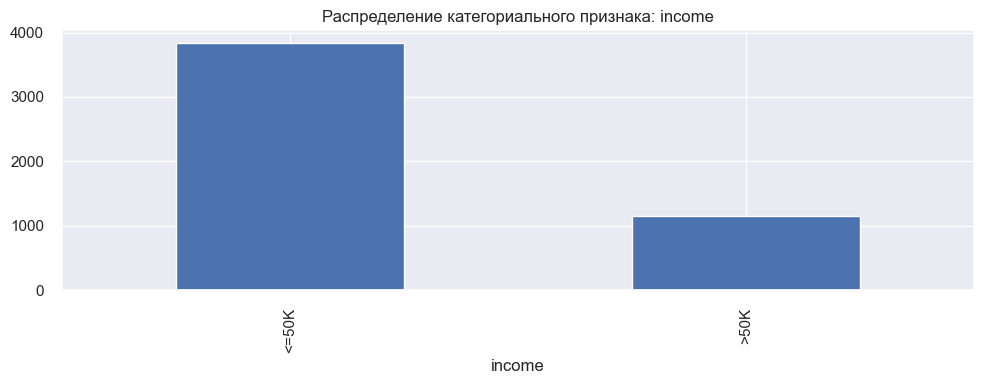

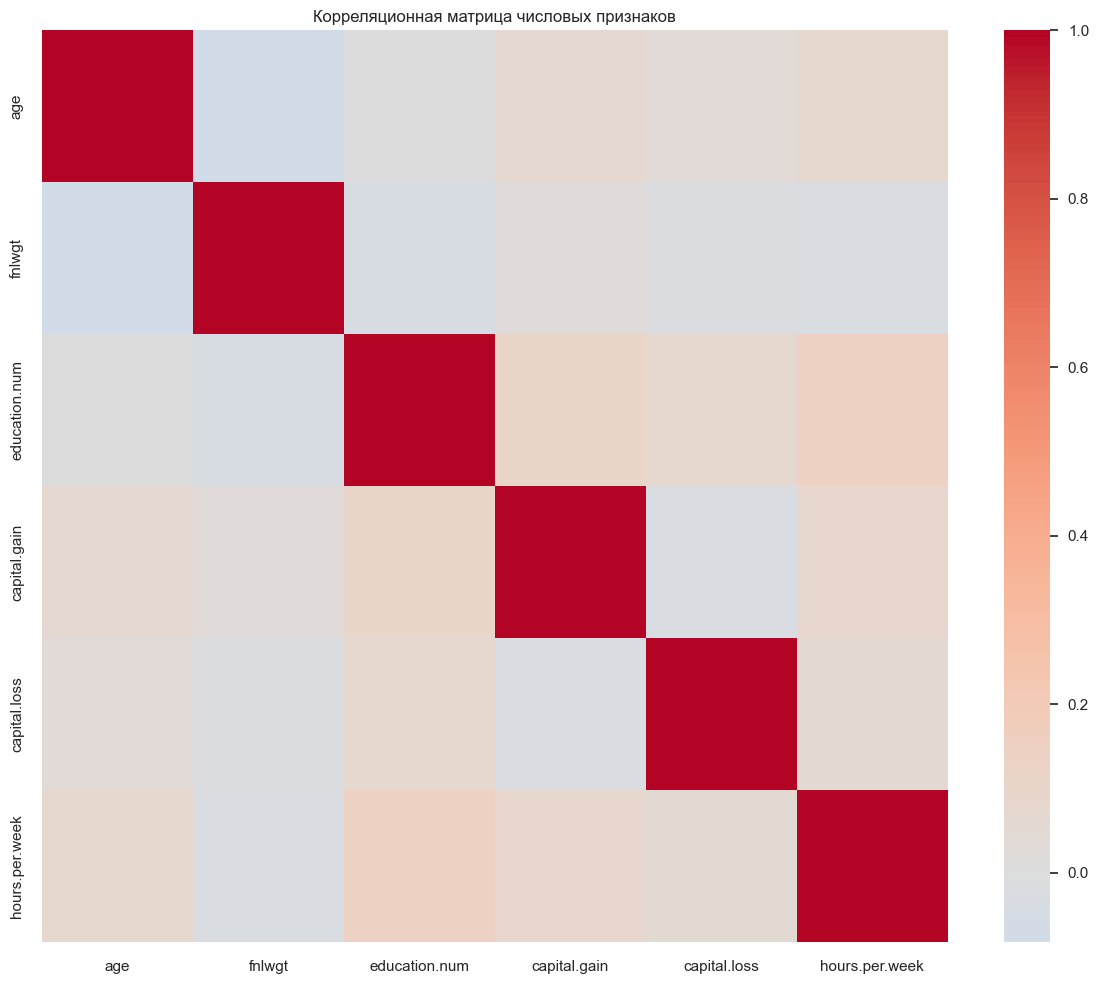

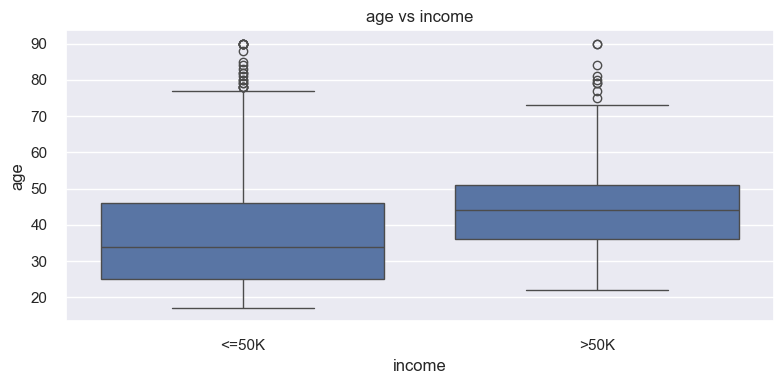

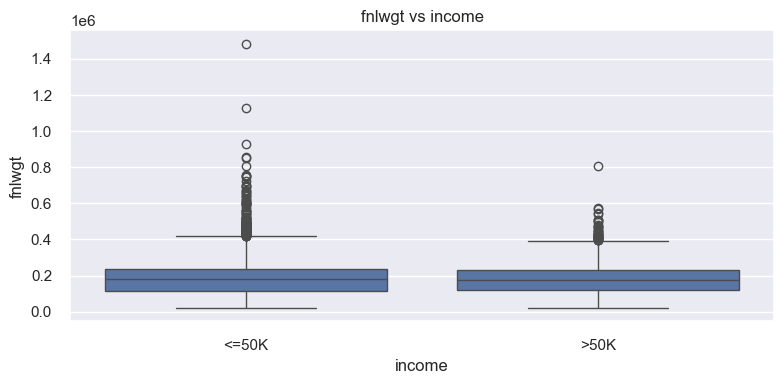

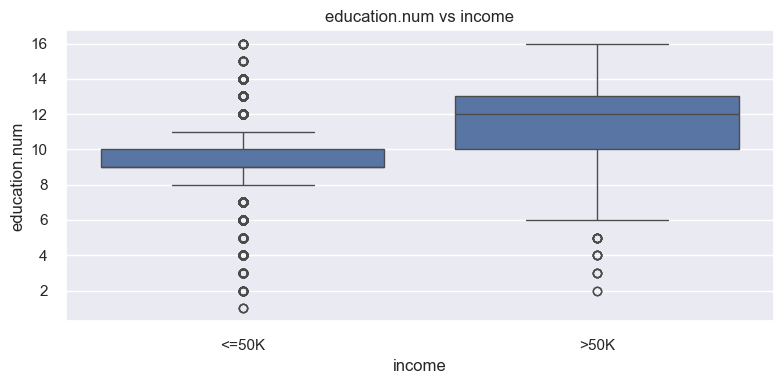

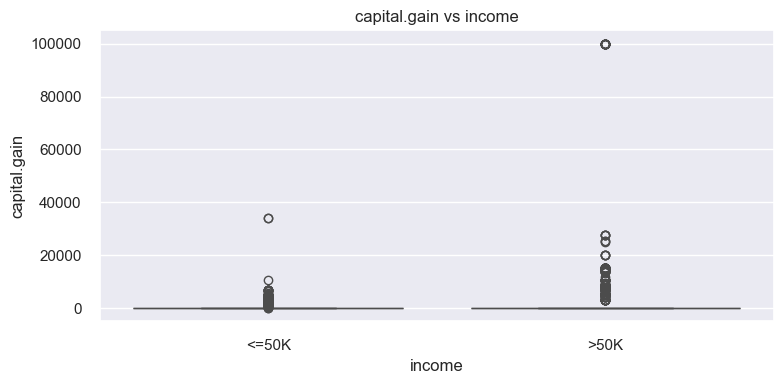

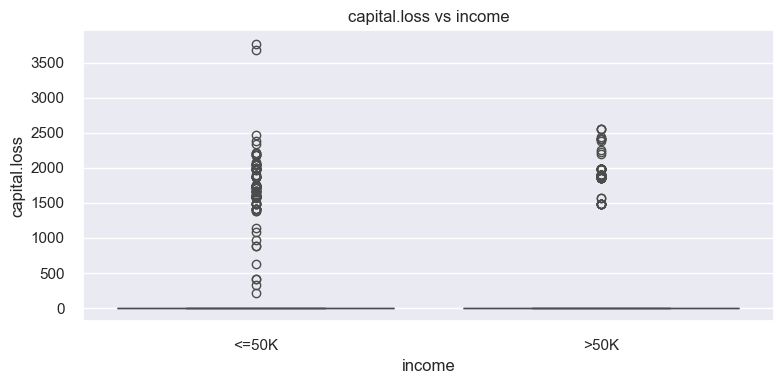

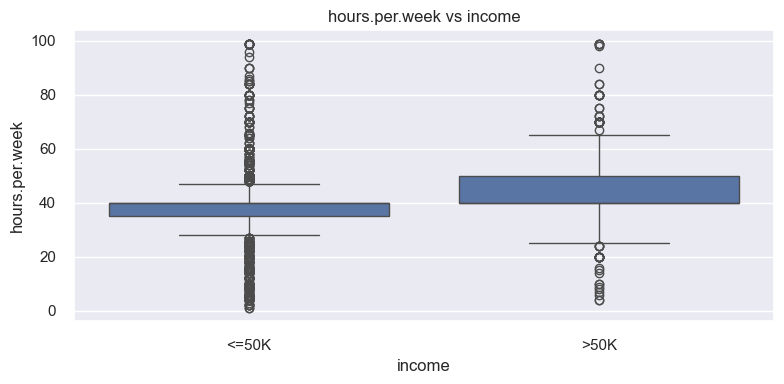

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_PATH = os.path.join("..", "datasets", "adult", "adult.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv(DATA_PATH)

print("Форма датасета:", df.shape)
display(df.head())

print("\nТипы столбцов:")
print(df.dtypes)

print("\nИнформация о данных:")
df.info()

print("\nОписательная статистика числовых признаков:")
display(df.describe(include=[np.number]).T)

print("\nОписательная статистика категориальных признаков:")
display(df.describe(include=["object", "category"]).T)

print("\nЧисло дубликатов:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
print("\nПропуски по столбцам:")
display(missing[missing > 0])

target_col = "income"

if target_col in df.columns:
    print("\nРаспределение целевой переменной:")
    display(df[target_col].value_counts())
    print("\nДоля классов:")
    display(df[target_col].value_counts(normalize=True))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

sample_df = df.sample(n=min(len(df), 5000), random_state=42)

if numeric_cols:
    sample_df[numeric_cols].hist(bins=30, figsize=(16, 12))
    plt.suptitle("Распределения числовых признаков")
    plt.show()

if categorical_cols:
    for col in categorical_cols:
        plt.figure(figsize=(10, 4))
        sample_df[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Распределение категориального признака: {col}")
        plt.tight_layout()
        plt.show()

if numeric_cols:
    plt.figure(figsize=(12, 10))
    corr = sample_df[numeric_cols].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Корреляционная матрица числовых признаков")
    plt.tight_layout()
    plt.show()

if target_col in df.columns:
    for col in numeric_cols[:8]:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=target_col, y=col, data=sample_df)
        plt.title(f"{col} vs {target_col}")
        plt.tight_layout()
        plt.show()
